In [ ]:
from google.colab import drive
import os
import shutil

# Ensure the mount point is clean
if os.path.exists('/content/drive'):
    if os.path.ismount('/content/drive'):
        print('Unmounting existing drive...')
        try:
            !fusermount -u /content/drive
            # Give it a moment to unmount fully
            import time
            time.sleep(2)
        except Exception as e:
            print(f"Warning: Could not unmount /content/drive: {e}")

    # Attempt to remove the directory if it's not a mount point anymore or if unmount failed
    if os.path.exists('/content/drive') and not os.path.ismount('/content/drive'):
        print('Removing /content/drive directory')
        shutil.rmtree('/content/drive', ignore_errors=True)

# Re-create the directory if it was removed
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import time
import math
import pandas as pd
from tqdm import tqdm
from PIL import Image
from scipy.signal import medfilt
from scipy.spatial.distance import pdist
from sklearn.metrics import roc_curve, auc, DetCurveDisplay
from scipy.stats import norm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

Device in use: cuda


# Image Pre-processing
### ROI extraction and saving functions

In [ ]:
def find_finger_boundary_lee(img):
    height, width = img.shape
    pad_size = 40
    padded_img = cv2.copyMakeBorder(img, pad_size, pad_size, 0, 0, cv2.BORDER_CONSTANT, value=0)
    padded_height = padded_img.shape[0]

    upper_mask = np.vstack([np.full((2, 20), -1), np.full((2, 20), 1)])
    lower_mask = np.vstack([np.full((2, 20), 1), np.full((2, 20), -1)])

    img_float = padded_img.astype(np.float32)
    upper_response = cv2.filter2D(img_float, cv2.CV_32F, upper_mask)
    lower_response = cv2.filter2D(img_float, cv2.CV_32F, lower_mask)

    mid_y = padded_height // 2
    upper_response[mid_y + 40:, :] = -1e9
    lower_response[:mid_y - 40, :] = -1e9

    upper_boundary = np.argmax(upper_response, axis=0) - pad_size
    lower_boundary = np.argmax(lower_response, axis=0) - pad_size

    upper_boundary = np.clip(upper_boundary, 0, height - 1)
    lower_boundary = np.clip(lower_boundary, 0, height - 1)

    upper_boundary = medfilt(upper_boundary, kernel_size=71).astype(int)
    lower_boundary = medfilt(lower_boundary, kernel_size=71).astype(int)

    c_start, c_end = int(width * 0.25), int(width * 0.75)
    ref_upper = int(np.median(upper_boundary[c_start:c_end]))
    ref_lower = int(np.median(lower_boundary[c_start:c_end]))
    ref_width = ref_lower - ref_upper
    max_dev   = int(ref_width * 0.25)

    for x in range(width):
        if upper_boundary[x] < ref_upper - max_dev or upper_boundary[x] > ref_upper + max_dev:
            upper_boundary[x] = ref_upper
        if lower_boundary[x] < ref_lower - max_dev or lower_boundary[x] > ref_lower + max_dev:
            lower_boundary[x] = ref_lower

    upper_boundary = medfilt(upper_boundary.astype(float), kernel_size=71).astype(int)
    lower_boundary = medfilt(lower_boundary.astype(float), kernel_size=71).astype(int)

    upper_boundary = np.clip(upper_boundary, 0, height - 1)
    lower_boundary = np.clip(lower_boundary, 0, height - 1)

    return upper_boundary, lower_boundary

def compute_centerline(upper, lower):
    return (upper + lower) / 2

def align_finger(img, upper, lower):
    width = img.shape[1]
    centerline = compute_centerline(upper, lower)
    x = np.arange(width)
    valid = (upper > 0) & (lower < img.shape[0] - 1)

    angle = 0.0
    if np.sum(valid) > 1:
        coeffs = np.polyfit(x[valid], centerline[valid], 1)
        angle = np.degrees(np.arctan(coeffs[0]))

    if abs(angle) > 1.0:
        cx, cy = width // 2, img.shape[0] // 2
        M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        aligned = cv2.warpAffine(img, M, (width, img.shape[0]), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
    else:
        aligned = img.copy()

    return aligned, angle

def extract_roi_yang(aligned_img, upper_bound, lower_bound, roi_height=96, roi_width=256):
    height, width = aligned_img.shape
    x_start, x_end = int(width * 0.15), int(width * 0.85)
    cropped_width = x_end - x_start
    normalized_strip = np.zeros((roi_height, cropped_width), dtype=np.uint8)
    valid_mask = np.zeros(cropped_width, dtype=bool)

    c_start, c_end = int(width * 0.25), int(width * 0.75)
    finger_widths  = lower_bound[c_start:c_end] - upper_bound[c_start:c_end]
    median_hw      = int(np.median(finger_widths) * 0.4)

    for idx, x in enumerate(range(x_start, x_end)):
        center_y = int((upper_bound[x] + lower_bound[x]) / 2)
        src_y_start = max(0, center_y - median_hw)
        src_y_end   = min(height, center_y + median_hw)

        col_pixels = aligned_img[src_y_start:src_y_end, x]
        if len(col_pixels) < 5 or np.median(col_pixels) < 20:
            continue
        non_black = np.where(col_pixels > 15)[0]
        if len(non_black) < int(len(col_pixels) * 0.5):
            continue

        finger_column = aligned_img[src_y_start:src_y_end, x:x+1]
        if finger_column.shape[0] > 0:
            column_resized = cv2.resize(finger_column, (1, roi_height), interpolation=cv2.INTER_LINEAR)
            normalized_strip[:, idx] = column_resized.flatten()
            valid_mask[idx] = True

    valid_cols = np.where(valid_mask)[0]
    if len(valid_cols) > 0:
        for idx in range(cropped_width):
            if not valid_mask[idx]:
                nearest = valid_cols[np.argmin(np.abs(valid_cols - idx))]
                normalized_strip[:, idx] = normalized_strip[:, nearest]

    roi = cv2.resize(normalized_strip, (roi_width, roi_height), interpolation=cv2.INTER_CUBIC)
    return roi

def enhance_and_normalize_roi(roi_img, clip_limit=2.0, tile_grid_size=(8, 8)):
    blurred = cv2.GaussianBlur(roi_img, (3, 3), 0)
    normalized_img = cv2.normalize(blurred, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced_roi = clahe.apply(normalized_img)
    return enhanced_roi

def process_and_save_dataset(input_base_dir, output_base_dir):
    os.makedirs(output_base_dir, exist_ok=True)
    image_paths = []
    for root, dirs, files in os.walk(input_base_dir):
        for file in files:
            if file.lower().endswith('.bmp'):
                image_paths.append(os.path.join(root, file))

    print(f"Found {len(image_paths)} images to process")
    for img_path in tqdm(image_paths, desc="ROI elaboration"):
        rel_path = os.path.relpath(img_path, input_base_dir)
        out_path = os.path.join(output_base_dir, rel_path)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        if os.path.exists(out_path): continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        try:
            upper_init, lower_init = find_finger_boundary_lee(img)
            aligned, _ = align_finger(img, upper_init, lower_init)
            upper_aligned, lower_aligned = find_finger_boundary_lee(aligned)
            roi = extract_roi_yang(aligned, upper_aligned, lower_aligned, roi_height=96, roi_width=256)
            final_roi = enhance_and_normalize_roi(roi, clip_limit=2.5, tile_grid_size=(8, 8))
            cv2.imwrite(out_path, final_roi)
        except Exception as e:
            print(f"Error on {img_path}: {e}")

*(Run the cell only if ROIs need to be generated)*

In [ ]:
input_dataset_path = '/content/drive/MyDrive/MMCBNU_6000/MMCBNU_6000/MMCBNU_6000/Captured_images/'
output_dataset_path = '/content/drive/MyDrive/MMCBNU_6000_ROI/'
process_and_save_dataset(input_dataset_path, output_dataset_path)

Found 6015 images to process


ROI elaboration: 100%|██████████| 6015/6015 [00:59<00:00, 100.79it/s]


# Preparation for Two-Fold Cross Validation


Class to load datasets based on the requested portion of subjects.

In [ ]:
class FingerVeinDataset(Dataset):
    def __init__(self, base_dir, subject_list, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Filter past subjects (e.g. 1 to 50)
        subjects = sorted([f"{s:03d}" for s in subject_list])
        class_idx = 0

        for sub in subjects:
            sub_dir = os.path.join(base_dir, sub)
            if not os.path.exists(sub_dir): continue

            fingers = sorted([f for f in os.listdir(sub_dir) if os.path.isdir(os.path.join(sub_dir, f))])
            for finger in fingers:
                finger_dir = os.path.join(sub_dir, finger)
                for img_name in os.listdir(finger_dir):
                    if img_name.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(finger_dir, img_name))
                        self.labels.append(class_idx)
                class_idx += 1 # Each finger is a distinct identity/class

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(self.labels[idx], dtype=torch.long)



train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Light variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformations for Testing (without augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ROI_DIR = '/content/drive/MyDrive/MMCBNU_6000_ROI/'


# Training, Score Extraction and Model Functions

In [ ]:

EMBEDDING_SIZE = 512

class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

def get_resnet_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, EMBEDDING_SIZE)
    return model.to(device)

def get_vgg_model():
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # Pooling modification
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    # Replacing the original classifier with a Flatten and a Linear layer towards the 512 of the ArcFace
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, EMBEDDING_SIZE) # 512
    )
    return model.to(device)

def train_model_arcface(model, train_loader, num_classes, num_epochs=20, lr=1e-4, weight_decay=1e-4):
    arcface_layer = ArcFace(in_features=EMBEDDING_SIZE, out_features=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam([
        {'params': model.parameters()},
        {'params': arcface_layer.parameters()}
    ], lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    model.train()
    arcface_layer.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            features = model(inputs)
            outputs = arcface_layer(features, labels)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loop.set_postfix(loss=loss.item())

        scheduler.step()

        epoch_loss = running_loss / total
        epoch_acc = (correct / total) * 100
        print(f"End Epoch {epoch+1}/{num_epochs} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

    return model

def extract_and_compute_scores(model, test_loader):
    model.eval()
    embeddings_list, labels_list = [], []
    num_samples = 0

    with torch.no_grad():
        dummy_input = torch.randn(2, 3, 224, 224, device=device)
        for _ in range(3):
            _ = model(dummy_input)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        # Initialize a net time counter
        total_inf_time = 0.0

        for imgs, lbls in tqdm(test_loader, desc="Extracting Features", leave=False):
            imgs = imgs.to(device)

            # Sync and start timer here
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start_time = time.time()

            # Only inference
            features = model(imgs)

            # Sync and stop the timer immediately after
            if device.type == 'cuda':
                torch.cuda.synchronize()
            total_inf_time += (time.time() - start_time)

            # Post-processing excluded from the timer
            features = F.normalize(features, p=2, dim=1)
            embeddings_list.append(features.cpu().numpy())
            labels_list.append(lbls.numpy())
            num_samples += imgs.size(0)

    # Calculate the average usint the accumulated net time
    inference_time_ms = (total_inf_time / num_samples) * 1000

    embeddings = np.concatenate(embeddings_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)


    distances = pdist(embeddings, metric='cosine') # Use cosine distance
    i, j = np.triu_indices(len(labels), k=1)
    genuine_impostor_labels = (labels[i] == labels[j]).astype(int)
    scores = -distances

    params_M = sum(p.numel() for p in model.parameters()) / 1e6
    return scores.tolist(), genuine_impostor_labels.tolist(), inference_time_ms, params_M


# Two-Fold Cross-Validation & Score Pooling

In [ ]:
import os

MODELS_DIR = '/content/drive/MyDrive/MMCBNU_6000_Models/'
os.makedirs(MODELS_DIR, exist_ok=True)

folds = [
    {'train': list(range(1, 51)), 'test': list(range(51, 101))},
    {'train': list(range(51, 101)), 'test': list(range(1, 51))}
]

# Global dictionary for collecting combined scores (POOL)
pooled_results = {
    'ResNet-18': {'scores': [], 'labels': [], 'inf_times': [], 'params_M': 0},
    'VGG-16': {'scores': [], 'labels': [], 'inf_times': [], 'params_M': 0}
}

for fold_idx, splits in enumerate(folds, 1):
    print(f"\n{'='*50}\n FOLD PROCESSING {fold_idx}\n{'='*50}")
    train_subs = splits['train']
    test_subs = splits['test']

    train_dataset = FingerVeinDataset(ROI_DIR, train_subs, transform=train_transforms)
    test_dataset  = FingerVeinDataset(ROI_DIR, test_subs, transform=test_transforms)

    num_classes = len(set(train_dataset.labels))
    print(f"-> Train subjects: {len(train_subs)} (Classes: {num_classes}). Test subjects: {len(test_subs)}.")

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    # -------------------
    # RESNET-18 Pipeline
    # -------------------
    print("\n[1/2] ResNet-18")
    resnet_path = os.path.join(MODELS_DIR, f'resnet18_arcface_fold{fold_idx}.pth')

    resnet = get_resnet_model()

    if os.path.exists(resnet_path):
        print(f"  -> [OK] Pre-trained model found! Loading weights from Drive.")
        resnet.load_state_dict(torch.load(resnet_path, map_location=device))
    else:
        print(f"  -> [INFO] No models saved. Starting training")
        resnet = train_model_arcface(resnet, train_loader, num_classes=num_classes, num_epochs=20, lr=1e-4)
        torch.save(resnet.state_dict(), resnet_path)
        print(f"  -> Model successfully saved to Drive.")

    scores, gen_imp_lbls, inf_time, params = extract_and_compute_scores(resnet, test_loader)

    # Data accumulation in the Pool
    pooled_results['ResNet-18']['scores'].extend(scores)
    pooled_results['ResNet-18']['labels'].extend(gen_imp_lbls)
    pooled_results['ResNet-18']['inf_times'].append(inf_time)
    pooled_results['ResNet-18']['params_M'] = params
    del resnet # Free GPU memory
    torch.cuda.empty_cache()

    # -------------------
    # VGG-16 Pipeline
    # -------------------
    print("\n[2/2] VGG-16")
    vgg_path = os.path.join(MODELS_DIR, f'vgg16_arcface_fold{fold_idx}.pth')
    vgg = get_vgg_model()

    if os.path.exists(vgg_path):
        print(f"  -> [OK] Pre-trained model found! Loading weights from Drive.")
        vgg.load_state_dict(torch.load(vgg_path, map_location=device))
    else:
        print(f"  -> [INFO] No models saved. Starting training")
        vgg = train_model_arcface(vgg, train_loader, num_classes=num_classes, num_epochs=20, lr=1e-4)
        torch.save(vgg.state_dict(), vgg_path)
        print(f"  -> Model successfully saved to Drive.")

    scores, gen_imp_lbls, inf_time, params = extract_and_compute_scores(vgg, test_loader)

    pooled_results['VGG-16']['scores'].extend(scores)
    pooled_results['VGG-16']['labels'].extend(gen_imp_lbls)
    pooled_results['VGG-16']['inf_times'].append(inf_time)
    pooled_results['VGG-16']['params_M'] = params
    del vgg
    torch.cuda.empty_cache()

print("\n All models processed successfully!")


 FOLD PROCESSING 1
-> Train subjects: 50 (Classes: 300). Test subjects: 50.

[1/2] ResNet-18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


  -> [OK] Pre-trained model found! Loading weights from Drive.



[2/2] VGG-16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.9MB/s]


  -> [OK] Pre-trained model found! Loading weights from Drive.



 FOLD PROCESSING 2
-> Train subjects: 50 (Classes: 300). Test subjects: 50.

[1/2] ResNet-18
  -> [OK] Pre-trained model found! Loading weights from Drive.



[2/2] VGG-16
  -> [OK] Pre-trained model found! Loading weights from Drive.



 All models processed successfully!


# Evaluation of Pooling Results

In [ ]:
from IPython.display import display

def calculate_pooled_metrics(pooled_scores, pooled_labels):
    fpr, tpr, thresholds = roc_curve(pooled_labels, pooled_scores)
    roc_auc = auc(fpr, tpr)

    frr = 1 - tpr
    far = fpr

    eer_index = np.nanargmin(np.absolute(far - frr))
    eer = far[eer_index]
    eer_threshold = thresholds[eer_index]

    predictions = (pooled_scores >= eer_threshold).astype(int)
    accuracy = np.mean(predictions == pooled_labels) * 100

    return fpr, tpr, roc_auc, eer, accuracy, thresholds, far, frr, eer_threshold

final_metrics = {}
summary_data = []
model_names = ['ResNet-18', 'VGG-16']

for name in model_names:
    all_scores = np.array(pooled_results[name]['scores'])
    all_labels = np.array(pooled_results[name]['labels'])

    fpr, tpr, roc_auc, eer, acc, thresh, far, frr, eer_thresh = calculate_pooled_metrics(all_scores, all_labels)
    avg_inf_time = np.mean(pooled_results[name]['inf_times'])

    final_metrics[name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': roc_auc, 'eer': eer, 'acc': acc,
        'thresholds': thresh, 'far': far, 'frr': frr, 'eer_thresh': eer_thresh
    }

    summary_data.append({
        'Model': name,
        'EER (%)': eer * 100,
        'Accuracy (%)': acc,
        'AUC': roc_auc,
        'Parameters (Millions)': pooled_results[name]['params_M'],
        'Avg Inference Time (ms)': avg_inf_time
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round({'EER (%)': 3, 'Accuracy (%)': 2, 'AUC': 4, 'Parameters (Millions)': 2, 'Avg Inference Time (ms)': 2})
print("\n=== Pooled Global Results (Two-Fold CV) ===")
display(df_summary)


=== Pooled Global Results (Two-Fold CV) ===


,Model,EER (%),Accuracy (%),AUC,Parameters (Millions),Avg Inference Time (ms)
0,ResNet-18,1.305,98.69,0.9989,11.44,1.09
1,VGG-16,1.304,98.70,0.9984,14.98,4.77


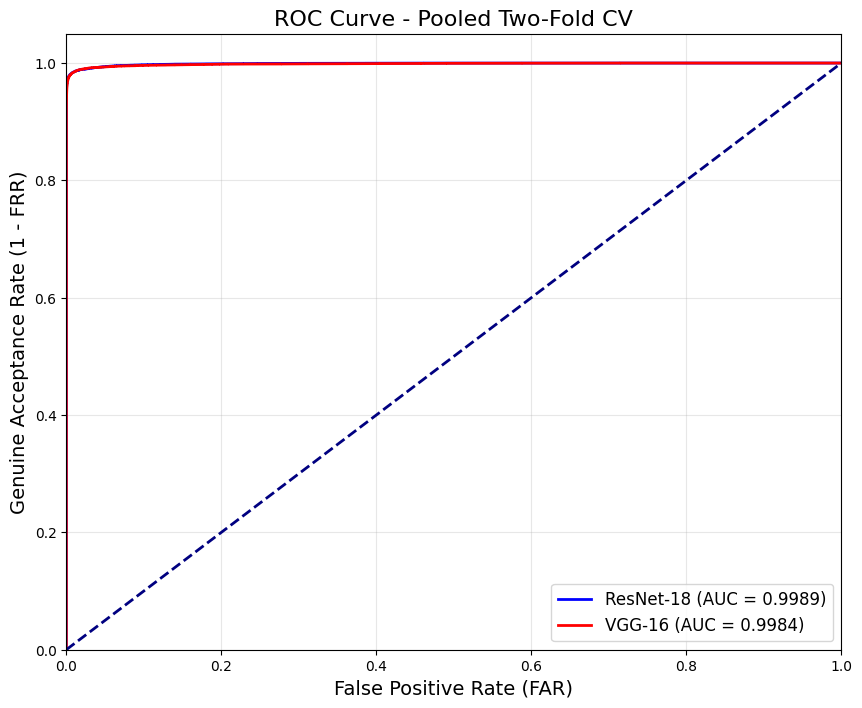

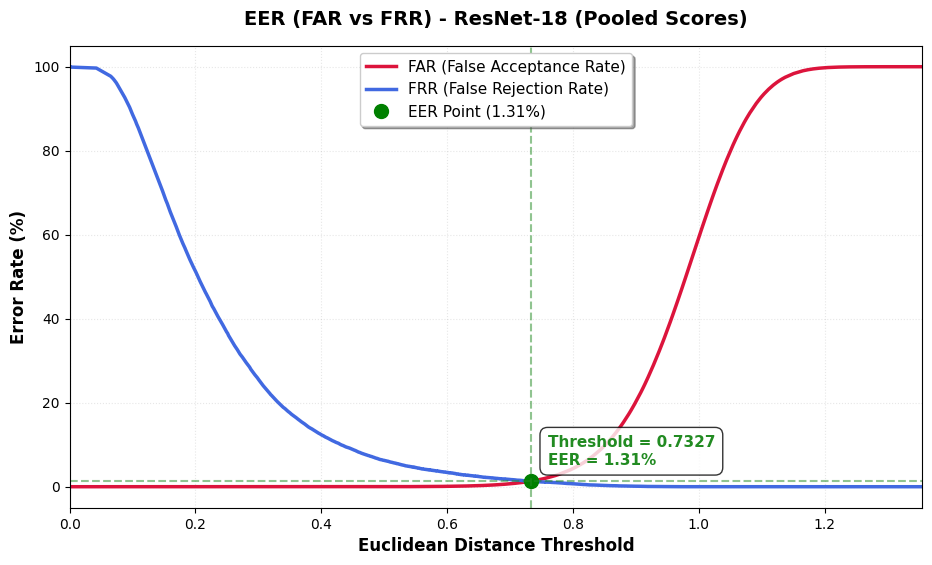

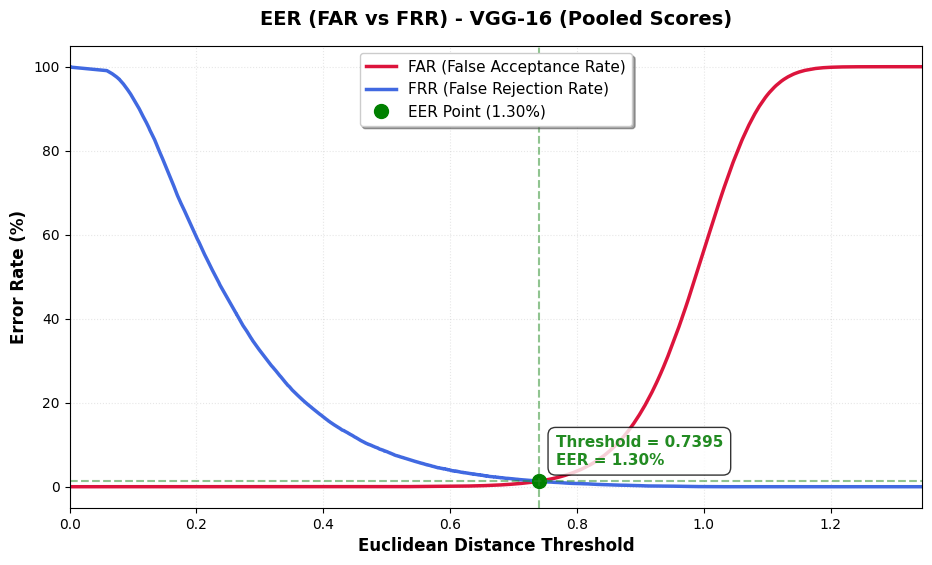

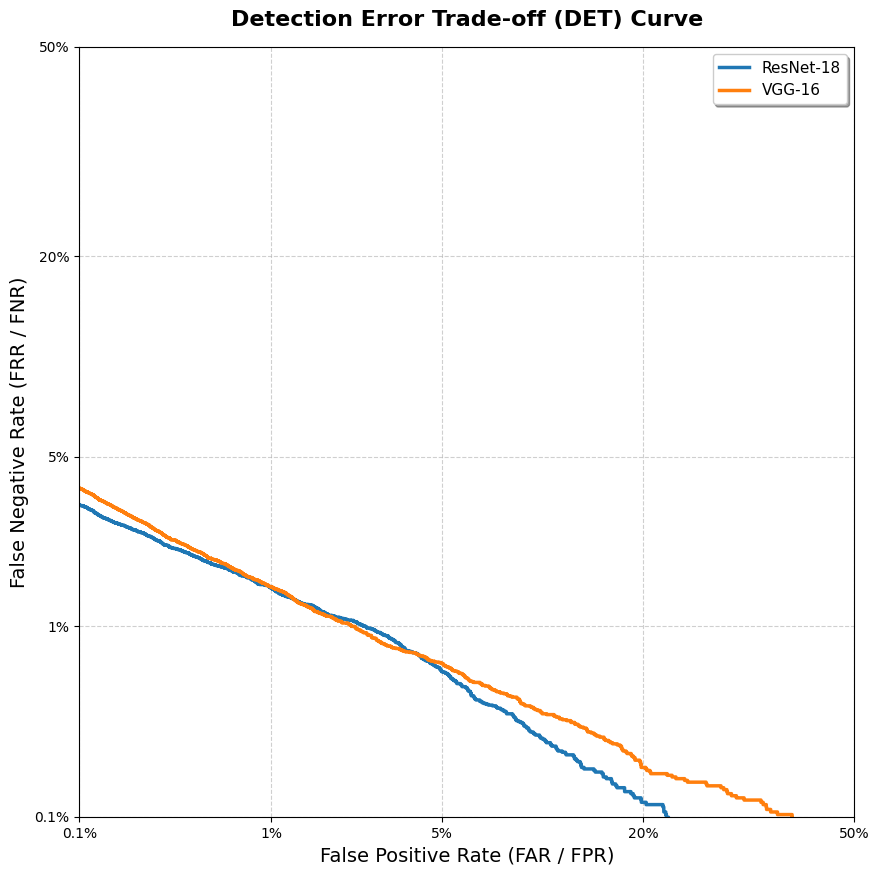

In [ ]:
# === UNIFIED ROC CURVE PLOT ===
plt.figure(figsize=(10, 8))
colors = ['blue', 'red']

for idx, name in enumerate(model_names):
    plt.plot(final_metrics[name]['fpr'], final_metrics[name]['tpr'], color=colors[idx], lw=2,
             label=f'{name} (AUC = {final_metrics[name]["auc"]:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FAR)', fontsize=14)
plt.ylabel('Genuine Acceptance Rate (1 - FRR)', fontsize=14)
plt.title('ROC Curve - Pooled Two-Fold CV', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# === EER PLOT FOR EACH MODEL ===
def generate_eer_pooled_graphic(model_name):
    far_pct = final_metrics[model_name]['far'] * 100
    frr_pct = final_metrics[model_name]['frr'] * 100
    dist_thresholds = -final_metrics[model_name]['thresholds'] # Reset to Euclidean Distance
    eer_val = final_metrics[model_name]['eer'] * 100
    eer_dist_thresh = -final_metrics[model_name]['eer_thresh']

    plt.figure(figsize=(11, 6))
    plt.plot(dist_thresholds[1:], far_pct[1:], color='crimson', lw=2.5, label='FAR (False Acceptance Rate)')
    plt.plot(dist_thresholds[1:], frr_pct[1:], color='royalblue', lw=2.5, label='FRR (False Rejection Rate)')

    plt.plot(eer_dist_thresh, eer_val, 'go', markersize=10, label=f'EER Point ({eer_val:.2f}%)')
    plt.axhline(y=eer_val, color='forestgreen', linestyle='--', alpha=0.5)
    plt.axvline(x=eer_dist_thresh, color='forestgreen', linestyle='--', alpha=0.5)

    plt.text(eer_dist_thresh + (max(dist_thresholds[1:]) * 0.02), eer_val + 4,
             f'Threshold = {eer_dist_thresh:.4f}\nEER = {eer_val:.2f}%',
             color='forestgreen', weight='bold', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

    plt.xlim([min(dist_thresholds[1:]), max(dist_thresholds[1:])])
    plt.ylim([-5, 105])
    plt.xlabel('Euclidean Distance Threshold', fontsize=12, weight='bold')
    plt.ylabel('Error Rate (%)', fontsize=12, weight='bold')
    plt.title(f'EER (FAR vs FRR) - {model_name} (Pooled Scores)', fontsize=14, weight='bold', pad=15)
    plt.legend(loc='upper center', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.show()

generate_eer_pooled_graphic('ResNet-18')
generate_eer_pooled_graphic('VGG-16')

# === UNIFIED CURVE PLOT ===
fig, ax = plt.subplots(figsize=(10, 10))

for name in model_names:
    all_labels = pooled_results[name]['labels']
    all_scores = pooled_results[name]['scores']

    DetCurveDisplay.from_predictions(
        all_labels,
        all_scores,
        name=f"{name}",
        ax=ax,
        linewidth=2.5
    )

ax.set_title('Detection Error Trade-off (DET) Curve', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('False Positive Rate (FAR / FPR)', fontsize=14)
ax.set_ylabel('False Negative Rate (FRR / FNR)', fontsize=14)

ax.grid(True, which="both", linestyle='--', alpha=0.6)

ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# === ZOOM CORRECTION ===
ax.set_xlim(norm.ppf(0.001), norm.ppf(0.50))
ax.set_ylim(norm.ppf(0.001), norm.ppf(0.50))

plt.show()